In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn


In [16]:
df = pd.read_csv('../wdi_poverty_panel_clean.csv')



In [17]:
df.head()

,country_name,country_code,year,electricity_access,agri_value_added,health_expenditure,fdi_inflows,gdp_growth,gdp_per_capita,education_expenditure,internet_users,inflation,life_expectancy,poverty_ratio,school_enrollment,unemployment,urban_population
0,Albania,ALB,2002,99.4,19.763916,5.598027,2.990031,4.628396,1479.838846,3.002530,0.390081,7.770526,75.299,4.2,110.338921,4.615,43.152042
1,Albania,ALB,2005,99.4,17.124718,5.662162,3.178998,5.130822,2741.721365,3.200240,6.043891,2.366582,76.427,2.7,107.016144,6.566,45.993767
2,Albania,ALB,2008,100.0,15.422100,5.444217,9.406653,6.907062,4498.504868,4.623305,23.860000,3.320871,78.248,0.8,100.383003,13.060,49.385070
3,Albania,ALB,2012,99.9,17.591369,6.085047,7.495975,0.984130,4280.933163,3.295340,49.400002,2.031593,78.084,1.8,102.067361,13.376,53.863755
4,Albania,ALB,2014,100.0,19.237759,6.358841,8.648466,2.240227,4793.597511,3.181777,54.299999,1.625865,78.029,3.7,105.770582,18.055,54.732581


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country_name           1671 non-null   object 
 1   country_code           1671 non-null   object 
 2   year                   1671 non-null   int64  
 3   electricity_access     1671 non-null   float64
 4   agri_value_added       1671 non-null   float64
 5   health_expenditure     1671 non-null   float64
 6   fdi_inflows            1671 non-null   float64
 7   gdp_growth             1671 non-null   float64
 8   gdp_per_capita         1671 non-null   float64
 9   education_expenditure  1671 non-null   float64
 10  internet_users         1671 non-null   float64
 11  inflation              1671 non-null   float64
 12  life_expectancy        1671 non-null   float64
 13  poverty_ratio          1671 non-null   float64
 14  school_enrollment      1671 non-null   float64
 15  unem

In [8]:
target_col = 'poverty_ratio'

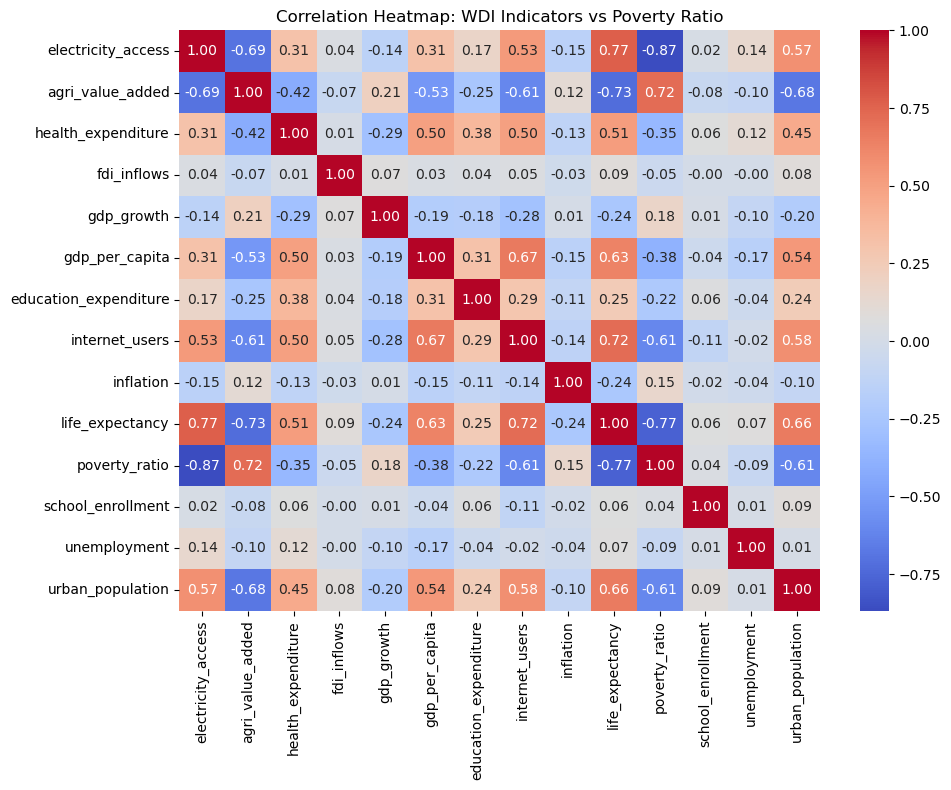

In [ ]:
# Correlation heatmap
corr = df.drop(columns=['country_name', 'country_code', 'year']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap: WDI Indicators vs Poverty Ratio')
plt.tight_layout()
plt.show()


Correlation heatmap: This shows how strongly each indicator relates to poverty, from -1 (opposite directions) to +1 (move together). Electricity access is the best negative indicator at -0.87 and life expectancy at -0.77, meaning that improvements in infrastructure and health lead to a decline in poverty, while agricultural share of GDP is the best positive indicator (+0.72), meaning that economies that are more agriculture-oriented tend to be poorer. School enrollment is almost zero and a negligible contribution as are FDI and unemployment, so they are to be possibly removed. Some predictors are also highly correlated in their relationships (life expectancy and electricity access is +0.77); they seem to have some level of redundancy which can be considered for later.

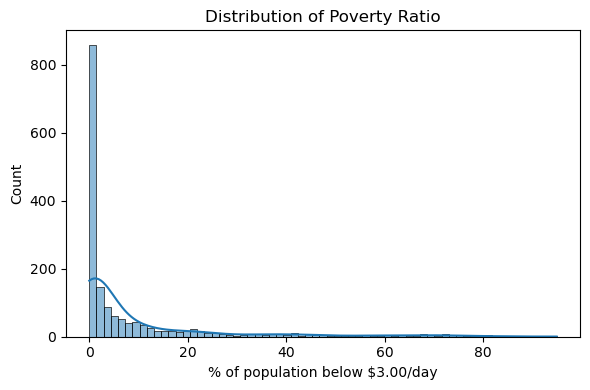

In [ ]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.histplot(df[target_col], kde=True)
plt.title('Distribution of Poverty Ratio')
plt.xlabel('% of population below $3.00/day')
plt.tight_layout()
plt.show()

Target Distribution: This indicates the distribution of the poverty_ratio across all observations. It is very skewed to the right, with lots of country-years that have low poverty, and a long tail of country-years with high poverty. This skew is important to note, as linear regression is based on a balanced spread, suggesting standardization of the data and possibly a log transformation may help.

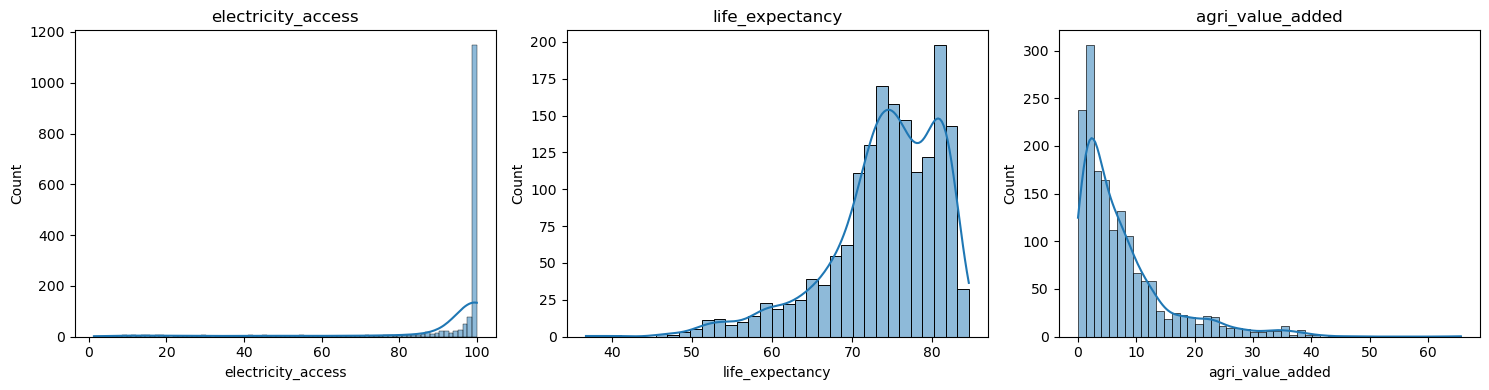

In [ ]:
# Top 3 predictor distributions (most correlated with target)
top_features = corr[target_col].abs().sort_values(ascending=False).index[1:4]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feature in zip(axes, top_features):
    sns.histplot(df[feature], kde=True, ax=ax)
    ax.set_title(feature)
plt.tight_layout()
plt.show()

Top predictor distributions: These illustrate the three most poverty-related indicators. They are all warped and have different scales and ranges, and therefore need to be standardized so that no one one variable is at a higher point simply due to raw number. They also allow for detection of any extreme outliers early on so that they do not affect the fit of the model.

In [19]:
# Drop near-zero-correlation predictors (justified by heatmap)
low_signal = ['school_enrollment', 'fdi_inflows', 'unemployment']

In [20]:
df = df.drop(columns=low_signal)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country_name           1671 non-null   object 
 1   country_code           1671 non-null   object 
 2   year                   1671 non-null   int64  
 3   electricity_access     1671 non-null   float64
 4   agri_value_added       1671 non-null   float64
 5   health_expenditure     1671 non-null   float64
 6   gdp_growth             1671 non-null   float64
 7   gdp_per_capita         1671 non-null   float64
 8   education_expenditure  1671 non-null   float64
 9   internet_users         1671 non-null   float64
 10  inflation              1671 non-null   float64
 11  life_expectancy        1671 non-null   float64
 12  poverty_ratio          1671 non-null   float64
 13  urban_population       1671 non-null   float64
dtypes: float64(11), int64(1), object(2)
memory usage: 182.9+

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [23]:
# Separate features (X) from target (y), dropping non-predictive columns
X = df.drop(columns=['country_name', 'country_code', 'year', 'poverty_ratio'])
y = df['poverty_ratio']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
X_train_scaled.shape

(1336, 10)

In [27]:
X_test_scaled.shape

(335, 10)

In [28]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# 1. Closed-form Linear Regression 
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_mse = mean_squared_error(y_test, lr.predict(X_test_scaled))

In [ ]:
# 2. Linear Regression via Gradient Descent (SGD)

sgd = SGDRegressor(max_iter=1, warm_start=True, random_state=42, learning_rate='constant', eta0=0.01)
n_epochs = 100
train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))
sgd_mse = test_losses[-1]


c:\Users\tenio\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\tenio\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\tenio\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\tenio\anaconda3\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1579: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\tenio\anaconda3\Lib\site-packages\sklearn\linea

In [34]:
# 3. Random Forest 
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
rf_mse = mean_squared_error(y_test, rf.predict(X_test_scaled))
